In [64]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
datadir0  ='//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/scripts/'
datadir0  ='//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/scripts/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


In [65]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]
    
def tolerant_mean(arrs):
    lens = [len(i) for i in arrs]
    #print(lens)
    arr = np.ma.empty((np.max(lens),len(arrs)))
    arr.mask = True
    for idx, l in enumerate(arrs):
        #print(l)
        arr[:len(l),idx] = l
    return arr.mean(axis = -1), arr.std(axis=-1)
# Example function for exponential decay
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def add_segment(mp_index, t, mean_stress, std_stress, mean_strain, mean_stressZ, std_stressZ):
    t = np.asarray(t, dtype=float).copy()
    mean_stress = np.asarray(mean_stress, dtype=float).copy()
    mean_stressZ = np.asarray(mean_stressZ, dtype=float).copy()
    std_stress  = np.asarray(std_stress, dtype=float).copy()
    std_stressZ  = np.asarray(std_stressZ, dtype=float).copy()
    mean_strain = np.asarray(mean_strain, dtype=float).copy()

    n = min(len(t), len(mean_stress), len(std_stress), len(mean_strain))
    if n == 0:
        return

    stress_segments[mp_index].append(
        (t[:n], mean_stress[:n], std_stress[:n], mean_strain[:n], mean_stressZ[:n], std_stressZ[:n])
    )

def write_mp_file(mp_index, mp_value,nameanchor):
    if len(stress_segments[mp_index]) == 0:
        print("No segments for MP", mp_value)
        return

    t_all      = np.concatenate([seg[0] for seg in stress_segments[mp_index]])
    stress_all = np.concatenate([seg[1] for seg in stress_segments[mp_index]])
    std_all    = np.concatenate([seg[2] for seg in stress_segments[mp_index]])
    strain_all = np.concatenate([seg[3] for seg in stress_segments[mp_index]])
    stress_allZ = np.concatenate([seg[4] for seg in stress_segments[mp_index]])
    std_allZ = np.concatenate([seg[5] for seg in stress_segments[mp_index]])

    order = np.argsort(t_all)

    df = pandas.DataFrame({
        "Time":     t_all[order],
        "AvStress": stress_all[order],
        "StdStress":std_all[order],
        "Strain":   strain_all[order],
        "AvStressZ":   stress_allZ[order],
        "StdStressZ":   std_allZ[order],
    })

    fname = outdir / f"{nameanchor}_MP{mp_value}.dat"
    df.to_csv(fname, sep=" ", index=False, float_format="%.8g")
    print("Wrote", fname)



In [66]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time at end of stress data: 164030.0  time at beginnning stress data 10.0


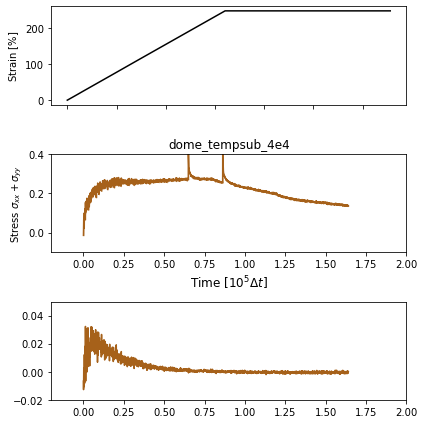

In [67]:
figNICE,axNICE=plt.subplots(3,1,figsize = (6,6))
tstr = "2e5".split()
Xstretches = "75".split()
Nevery = "5000".split()
MPs = "0.01 ".split() # 0.18 0.27 0.6 0.81 0.09 0.18 0.27 0.6 0.81 
MonPref = "15".split() # 13 17 26 31   8 6 6 9 9

seeds = "1".split()
x=0
mp=0
folder = 'dome_tempsub_4e4'
# where to save

Taus = np.zeros((len(MPs),len(seeds)))
StartTimes = np.zeros((len(MPs),len(seeds)))
Density = True #False
VolInit = (32.3*32.3*12)
n_MPs   = len(MPs)
n_seeds = len(seeds)
stress_segments = [[] for _ in range(n_MPs)]
# per-MP list of stress/time arrays from each seed
stress_traces = [[] for _ in range(n_MPs)]
stress_traces_Z = [[] for _ in range(n_MPs)]
strain_traces = [[] for _ in range(n_MPs)]
time_traces   = [[] for _ in range(n_MPs)]
indicesMPs = [0,1,2,3,4,5,6,7] #,2,3,4,5,6,7] #[0,1,3,5]
for x in range(len(MPs)):
    for s in range(len(seeds)):
        #if s==0 and x==6:
        foldername = datadir0 +folder +'/'
        filename = '/thermo.dat'
        #print(foldername)
        thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
        press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
        press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
        stressXN_,stressYN_,stressZN_ = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
        stressXN,stressYN,stressZN = stressXN_,stressYN_,stressZN_
        CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
        CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
        NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
        NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
        T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
        T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
        
        strain = np.multiply(
            np.subtract(np.sqrt(np.divide(BoxVol, BoxVol[0])), 1.0),
            100.0
        )
        NumTot = thermo.NumTot
        Time_ = thermo.step
        Time = Time_.values
        tStart = Time[0]
        tStr = tStart
        tEndStr = tStr+4.02e5
        tEndRel = tEndStr+1.0e5 #2e5
        time_plot  = np.add(Time,-Time[0])
        filename = '/thermo.dat'
        #tEndRel = tEndStr+5e4 #+1e6
        indexSt = np.argmin(np.abs(Time - tEndRel))
        indexPre = np.argmin(np.abs(Time - tEndStr))
        indexEnd = np.argmin(np.abs(Time - (tEndRel+5e5)))
        #print('Time[-1],tEndRel',Time[0],Time[-1],tEndRel,indexSt)
        StartTimes[x,s] = Time[0]
        N=2
       # print(MPs[mp],Time[0])
        stress = np.convolve(np.divide(np.add(stressXN,stressYN),BoxVol), np.ones(N)/N, mode='valid')
        stressFull = np.convolve(np.add(stressXN,stressYN), np.ones(N)/N, mode='valid')
        stressZ = np.convolve(np.divide(stressZN,BoxVol), np.ones(N)/N, mode='valid')
        TimeConv = np.convolve(Time, np.ones(N)/N, mode='valid')
    
        
    
        if x==0:
            axNICE[0].plot(np.divide(np.subtract(Time,Time[0]),1e5),np.multiply(np.subtract(np.sqrt(np.divide(BoxVol,BoxVol[0])),1),100),color = 'black')
        # store for averaging later
        t_rel = np.subtract(TimeConv, Time[0])
        stress_traces[x].append(stress)
        stress_traces_Z[x].append(stressZ)
        time_traces[x].append(t_rel)
        strain_traces[x].append(strain)
        
        #axNICE[1].plot(np.subtract(TimeConv,Time[0]), stress,color = clrs[x],alpha = 0.6)
        #axNICE[1].plot(np.add(np.subtract(TimeFit,Time[0]),TimeConv2[0]),exp_decay(TimeFit, *params), 'black',linestyle = ':', label="Fit")
        
    if len(stress_traces[x]) == 0:
        continue
    
    # truncate all seeds to the length of the shortest one
    min_len = min(arr.shape[0] for arr in stress_traces[x])
    
    stress_stack = np.stack([arr[:min_len] for arr in stress_traces[x]], axis=0)
    stress_stack_Z = np.stack([arr[:min_len] for arr in stress_traces_Z[x]], axis=0)
    
    time_stack   = np.stack([arr[:min_len] for arr in time_traces[x]],   axis=0)
    strain_stack = np.stack([arr[:min_len] for arr in strain_traces[x]], axis=0)
    
    # time should be aligned; just use the first seed’s (or mean if you prefer)
    t = time_stack[0]
    print("Time at end of stress data:",t[-1], " time at beginnning stress data", t[0])
    stress_mean = np.mean(stress_stack, axis=0)
    stress_mean_Z = np.mean(stress_stack_Z, axis=0)
    strain_mean = np.mean(strain_stack, axis=0)
    stress_std  = np.std(stress_stack, axis=0)
    stress_std_Z  = np.std(stress_stack_Z, axis=0)
    add_segment(x, t, stress_mean, stress_std, strain_mean,stress_mean_Z,stress_std_Z)
    
    # plot mean
    axNICE[1].plot(np.divide(t,1e5), stress_mean, color=clrs[x]) #, label =r'$T_{\mathrm{life}} = $'+str(np.round(np.divide(TLifeDenseControl[x],1e6)).astype(int))+r'$\times10^6\Delta t$')
    axNICE[2].plot(np.divide(t,1e5), stress_mean_Z, color=clrs[x]) #, label =r'$T_{\mathrm{life}} = $'+str(np.round(np.divide(TLifeDenseControl[x],1e6)).astype(int))+r'$\times10^6\Delta t$')

    # plot ±1 std as a shaded band
    axNICE[1].fill_between(
        np.divide(t,1e5),
        stress_mean - stress_std,
        stress_mean + stress_std,
        color=clrs[x],
        alpha=0.3
    )   

axNICE[0].set_ylabel("Strain $[\%]$")
axNICE[1].set_ylabel("Stress $\sigma_{xx}+\sigma_{yy}$")
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 9,labelspacing=0.12)
axNICE[1].set_title(folder)

axNICE[1].set_xlim([-0.2,2])
# axNICE[0].set_xlim([-1,4])
axNICE[2].set_xlim([-0.2,2])
axNICE[1].set_ylim([-0.1,0.4])
axNICE[2].set_ylim([-0.02,0.05])

figNICE.tight_layout()
plotname = "NewStretch40_profiles.pdf"
#figNICE.savefig(plotsdir+'NewStretch40_profiles.png', dpi=600)
#figNICE.savefig(plotsdir+plotname)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time at end of stress data: 141010.0  time at beginnning stress data 10.0


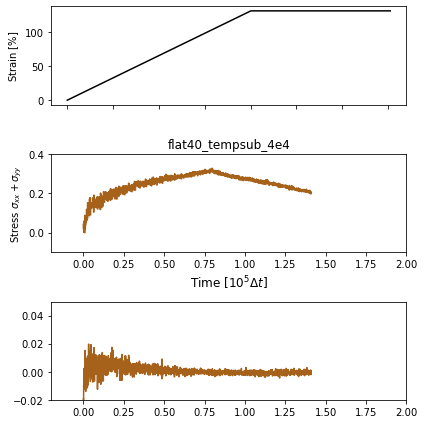

In [63]:
figNICE,axNICE=plt.subplots(3,1,figsize = (6,6))
tstr = "2e5".split()
Xstretches = "75".split()
Nevery = "5000".split()
MPs = "0.01 ".split() # 0.18 0.27 0.6 0.81 0.09 0.18 0.27 0.6 0.81 
MonPref = "15".split() # 13 17 26 31   8 6 6 9 9

seeds = "1".split()
x=0
mp=0
# where to save
folder = 'flat40_tempsub_4e4'
Taus = np.zeros((len(MPs),len(seeds)))
StartTimes = np.zeros((len(MPs),len(seeds)))
Density = True #False
VolInit = (32.3*32.3*12)
n_MPs   = len(MPs)
n_seeds = len(seeds)
stress_segments = [[] for _ in range(n_MPs)]
# per-MP list of stress/time arrays from each seed
stress_traces = [[] for _ in range(n_MPs)]
stress_traces_Z = [[] for _ in range(n_MPs)]
strain_traces = [[] for _ in range(n_MPs)]
time_traces   = [[] for _ in range(n_MPs)]
indicesMPs = [0,1,2,3,4,5,6,7] #,2,3,4,5,6,7] #[0,1,3,5]
for x in range(len(MPs)):
    for s in range(len(seeds)):
        #if s==0 and x==6:
        foldername = datadir0 + folder +'/'
        filename = '/thermo.dat'
        #print(foldername)
        thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
        press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
        press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
        stressXN_,stressYN_,stressZN_ = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
        stressXN,stressYN,stressZN = stressXN_,stressYN_,stressZN_
        CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
        CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
        NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
        NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
        T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
        T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
        
        strain = np.multiply(
            np.subtract(np.sqrt(np.divide(BoxVol, BoxVol[0])), 1.0),
            100.0
        )
        NumTot = thermo.NumTot
        Time_ = thermo.step
        Time = Time_.values
        tStart = Time[0]
        tStr = tStart
        tEndStr = tStr+4.02e5
        tEndRel = tEndStr+1.0e5 #2e5
        time_plot  = np.add(Time,-Time[0])
        filename = '/thermo.dat'
        #tEndRel = tEndStr+5e4 #+1e6
        indexSt = np.argmin(np.abs(Time - tEndRel))
        indexPre = np.argmin(np.abs(Time - tEndStr))
        indexEnd = np.argmin(np.abs(Time - (tEndRel+5e5)))
        #print('Time[-1],tEndRel',Time[0],Time[-1],tEndRel,indexSt)
        StartTimes[x,s] = Time[0]
        N=2
       # print(MPs[mp],Time[0])
        stress = np.convolve(np.divide(np.add(stressXN,stressYN),BoxVol), np.ones(N)/N, mode='valid')
        stressFull = np.convolve(np.add(stressXN,stressYN), np.ones(N)/N, mode='valid')
        stressZ = np.convolve(np.divide(stressZN,BoxVol), np.ones(N)/N, mode='valid')
        TimeConv = np.convolve(Time, np.ones(N)/N, mode='valid')
    
        
    
        if x==0:
            axNICE[0].plot(np.divide(np.subtract(Time,Time[0]),1e5),np.multiply(np.subtract(np.sqrt(np.divide(BoxVol,BoxVol[0])),1),100),color = 'black')
        # store for averaging later
        t_rel = np.subtract(TimeConv, Time[0])
        stress_traces[x].append(stress)
        stress_traces_Z[x].append(stressZ)
        time_traces[x].append(t_rel)
        strain_traces[x].append(strain)
        
        #axNICE[1].plot(np.subtract(TimeConv,Time[0]), stress,color = clrs[x],alpha = 0.6)
        #axNICE[1].plot(np.add(np.subtract(TimeFit,Time[0]),TimeConv2[0]),exp_decay(TimeFit, *params), 'black',linestyle = ':', label="Fit")
        
    if len(stress_traces[x]) == 0:
        continue
    
    # truncate all seeds to the length of the shortest one
    min_len = min(arr.shape[0] for arr in stress_traces[x])
    
    stress_stack = np.stack([arr[:min_len] for arr in stress_traces[x]], axis=0)
    stress_stack_Z = np.stack([arr[:min_len] for arr in stress_traces_Z[x]], axis=0)
    
    time_stack   = np.stack([arr[:min_len] for arr in time_traces[x]],   axis=0)
    strain_stack = np.stack([arr[:min_len] for arr in strain_traces[x]], axis=0)
    
    # time should be aligned; just use the first seed’s (or mean if you prefer)
    t = time_stack[0]
    print("Time at end of stress data:",t[-1], " time at beginnning stress data", t[0])
    stress_mean = np.mean(stress_stack, axis=0)
    stress_mean_Z = np.mean(stress_stack_Z, axis=0)
    strain_mean = np.mean(strain_stack, axis=0)
    stress_std  = np.std(stress_stack, axis=0)
    stress_std_Z  = np.std(stress_stack_Z, axis=0)
    add_segment(x, t, stress_mean, stress_std, strain_mean,stress_mean_Z,stress_std_Z)
    
    # plot mean
    axNICE[1].plot(np.divide(t,1e5), stress_mean, color=clrs[x]) #, label =r'$T_{\mathrm{life}} = $'+str(np.round(np.divide(TLifeDenseControl[x],1e6)).astype(int))+r'$\times10^6\Delta t$')
    axNICE[2].plot(np.divide(t,1e5), stress_mean_Z, color=clrs[x]) #, label =r'$T_{\mathrm{life}} = $'+str(np.round(np.divide(TLifeDenseControl[x],1e6)).astype(int))+r'$\times10^6\Delta t$')

    # plot ±1 std as a shaded band
    axNICE[1].fill_between(
        np.divide(t,1e5),
        stress_mean - stress_std,
        stress_mean + stress_std,
        color=clrs[x],
        alpha=0.3
    )   

axNICE[0].set_ylabel("Strain $[\%]$")
axNICE[1].set_ylabel("Stress $\sigma_{xx}+\sigma_{yy}$")
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 9,labelspacing=0.12)
axNICE[1].set_title(folder)
# axNICE[1].set_xlim([-1,4])
# axNICE[0].set_xlim([-1,4])
# axNICE[2].set_xlim([-1,4])
axNICE[1].set_xlim([-0.2,2])
# axNICE[0].set_xlim([-1,4])
axNICE[2].set_xlim([-0.2,2])
axNICE[1].set_ylim([-0.1,0.4])
axNICE[2].set_ylim([-0.02,0.05])

figNICE.tight_layout()
plotname = "NewStretch40_profiles.pdf"
#figNICE.savefig(plotsdir+'NewStretch40_profiles.png', dpi=600)
#figNICE.savefig(plotsdir+plotname)